In [2]:
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import nan
from functions import * # import functions from the .py file

from pylab import rcParams
rcParams["figure.figsize"] = 16, 4

PAYLOADSIZE = 14

if PAYLOADSIZE % 2 != 0:
    print("Alarm! the payload size is not even.")
NUM_16RND = (PAYLOADSIZE-2)//2 # how many 16 bits random number included in each frame
MAX_SEQ = 256 # (decimal) maximum seq number defined by the length of the seq, the length of seq is 1B

In [3]:
import sys
print(sys.executable)


/Users/ojmc/UNI/Trådlös_kommunikation/Project/wcnes-project2026/.venv/bin/python


**For a fair comparison between groups, must follow the output format below**
<br>$\color{red}{\text{timestamp\_rx }| \text{ len [hex] } \text{ seq [hex] } \text{ payload [hex] }| \text{rssi} }$
<br>$\text{ len [hex]}$ = payload length + 1 (seq. field length [1B])
<br>$\text{ payload [hex]}$ should start with the pseudo sequence number [2B], indicates the starting byte's position in the file.
***
*Example log file output for one frame with reciever timestamp xxxx, frame length, seq number and random payload, received signal strength.*
<br>15:17:18.394 |0f 46 bd f8 f7 ea 41 ac 1b be 05 a0 7f d2 09 d4 |  -91 CRC error
<br>$\color{red}{\text{delimiter for four variables is "|" and delimiter for the payload each byte is the space " ".}}$

## Log file

In [4]:
# define the file name
filename = "2_ASK"
# import file to jupyter notebook
df = readfile("./" + filename + ".csv")
# check the imported data first 10 lines
df.head(10)

,index,time_rx,rssi,seq,payload
0,0,2026-05-15 15:32:27.558,-106,155,13 48 43 38 70 be ff c0 53 c7 3f 91 a6 00
1,1,2026-05-15 15:32:27.823,-108,184,26 a0 53 14 96 eb c2 25 5f 24 94 83 c4 80
2,2,2026-05-15 15:32:28.092,-108,158,26 b8 20 7f 5f c9 17 d2 7d 71 37 22 7f e0
3,3,2026-05-15 15:32:28.359,-107,158,13 68 17 53 a7 02 1f e2 59 c2 57 42 00 eb
4,4,2026-05-15 15:32:28.623,-106,159,13 74 66 3e 48 e4 7c 30 f4 03 6c 72 be a0
5,5,2026-05-15 15:32:28.892,-106,160,13 90 63 78 c0 89 b1 51 b3 33 09 fa 65 a0
6,6,2026-05-15 15:32:29.165,-108,93,7f ff b8 0c dc 28 3a 16 e5 2f f3 47 80 00
7,7,2026-05-15 15:32:29.428,-107,191,2f 60 82 14 6c 0c 6d 98 f2 7d 35 6a 16 22
8,8,2026-05-15 15:32:29.696,-106,76,4e 90 84 ac 6b 44 59 38 3b b1 20 c5 95 a0
9,9,2026-05-15 15:32:30.235,-110,165,9b bc 5b ae 79 6a 9f f2 8c 6e ea ce 47 80


In [5]:
# delete packets of invalid length (aka. error in length field at variable receiver length config) (PAYLOADSIZE + 2B pesudo sequence number)
test = df[df.payload.apply(lambda x: len(x)==((PAYLOADSIZE)*3-1))]
test.reset_index(inplace=True)

# Time

## Definition

**Evaluation metric**
<br>*File Transmission Time: the total latency that certain amount of Data $F$ is delivered to the destination.*
<br> $File\ Delay = Rx\_timestamp[N] - Rx\_timestamp[0]$
<br> where $N$ is the last packet
***
**Interesting to look at**:
<br>*Timestamp difference*: $\Delta T[i] = Rx\_timestamp[i] - Tx\_timestamp[i]$
1. *Worst-case packet delay*: the delay of the packet that takes the longest time to traverse.
2. *Packet delay variation*: the std of the packet delay.

In [6]:
# compute the file delay
file_delay = df.time_rx[len(df) - 1] - df.time_rx[0]
# convert the timedelta to s
file_delay_s = np.timedelta64(file_delay, "ms").astype(int) / 1000
print(f"The time it takes to transfer the file is : {file_delay}, which is {file_delay_s} seconds.")

The time it takes to transfer the file is : 0 days 00:00:48.274000, which is 48.274 seconds.


# Reliability

## Definition

**Evaluation metric**
<br>*Quality of data transfer.*
<br>*Bit Reliability*: The ratio of data bits correctly delivered to the data sink.
<br>*Bit Error Rate*: The ratio of data bits incorrectly delivered to the data sink.
$$Bit\ Reliability = 1 - BER = 1 - \frac{Number\ of\ wrong\ bit}{Total\ Number\ of\ bit\ received}$$
<br>*Achieved Data Rate*: The bit error rate is calculated based on the received data only. Missing packets do not affect the bit error rate, but are reflected in the achievable data rate.

## Statistics

In [7]:
# compute the BER for all received packets
# return the in total ber for received file, error statistics and correct file content supposed to be transmitted
ber = compute_ber(test, PACKET_LEN=NUM_16RND*2)
bit_reliability = (1-ber)*100
print(f"Bit error rate [%]: {(ber*100):.8f}\t\t(in received packets within pseudo sequence + payload) ")
if len(df) < 1:
    print("Data rate [bit/s]: More than one packet required for analysis.")
else:
    print(f"Data rate [bit/s]: {(len(df)*NUM_16RND*2/file_delay_s):.8f}\t\t(directly impacted by missed packets) ")

The total number of packets transmitted by the tag is 128.
Bit error rate [%]: 43.96428571		(in received packets within pseudo sequence + payload) 
Data rate [bit/s]: 24.85810167		(directly impacted by missed packets) 


--- Inter-arrival gap analysis (single file) ---
Theoretical nominal:        288.4 ms (TX_DURATION + air_time)
Refined nominal (no spikes):268.8 ms  (67 gaps used)
Mean of all gaps:           487.6 ms

Received packets:           100
Estimated lost packets:     81
Estimated packets sent:     181
Estimated PER (gap-based):  44.75 %


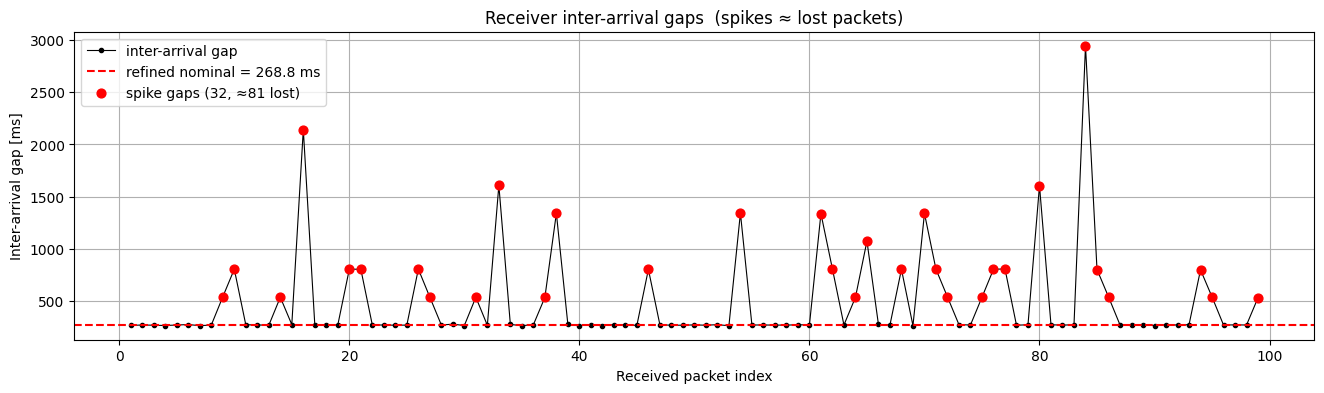

In [8]:
# Estimate lost packets from inter-arrival gaps.
#
# Approach:
#   1. Compute a rough theoretical nominal period (TX_DURATION + air_time).
#   2. Use that as a first-cut threshold to flag "obvious" spike gaps (where
#      packets were clearly missed).
#   3. Take the mean of the *non-spike* gaps — that's the true empirical
#      per-packet period, free of loss inflation.
#   4. Re-estimate loss count using the refined nominal.

TX_DURATION_MS  = 250
HEADER_BYTES    = 10                     # 4 preamble + 4 sync + 1 length + 1 seq
PAYLOAD_BYTES   = PAYLOADSIZE            # 14 (from main.c)
BAUD            = 5000

air_time_ms        = (HEADER_BYTES + PAYLOAD_BYTES) * 8 / BAUD * 1000
theoretical_ms     = TX_DURATION_MS + air_time_ms

gaps_ms = df.time_rx.diff().dt.total_seconds() * 1000

# Step 1: flag obvious spikes — anything ≥ 1.5× the theoretical nominal is
# almost certainly a gap that contains at least one missed packet.
rough_threshold_ms = 1.5 * theoretical_ms
clean_gaps         = gaps_ms[gaps_ms < rough_threshold_ms]

# Step 2: refined nominal = mean of clean gaps only.
nominal_ms = clean_gaps.mean()

# Step 3: count losses using the refined nominal.
est_lost   = ((gaps_ms / nominal_ms).round() - 1).clip(lower=0).fillna(0).astype(int)
total_lost = int(est_lost.sum())
total_sent = len(df) + total_lost

# === SANITY MARKER: edited from chat at this line ===
print(f"--- Inter-arrival gap analysis (single file) ---")
print(f"Theoretical nominal:        {theoretical_ms:.1f} ms (TX_DURATION + air_time)")
print(f"Refined nominal (no spikes):{nominal_ms:.1f} ms  ({len(clean_gaps)} gaps used)")
print(f"Mean of all gaps:           {gaps_ms.mean():.1f} ms")
print()
print(f"Received packets:           {len(df)}")
print(f"Estimated lost packets:     {total_lost}")
print(f"Estimated packets sent:     {total_sent}")
print(f"Estimated PER (gap-based):  {total_lost / total_sent * 100:.2f} %")

fig, ax = plt.subplots()
ax.plot(df.index, gaps_ms, marker="o", linewidth=0.8, markersize=3,
        color="black", label="inter-arrival gap")
ax.axhline(nominal_ms, color="red", linestyle="--",
           label=f"refined nominal = {nominal_ms:.1f} ms")

above = gaps_ms > nominal_ms * 1.5
ax.scatter(df.index[above], gaps_ms[above],
           color="red", s=40, zorder=5,
           label=f"spike gaps ({int(above.sum())}, ≈{total_lost} lost)")

ax.set_xlabel("Received packet index")
ax.set_ylabel("Inter-arrival gap [ms]")
ax.set_title("Receiver inter-arrival gaps  (spikes ≈ lost packets)")
ax.legend()
ax.grid(True)
plt.show()


Note: if individual packets have a high bit-error rate, it could be that the pseudo-sequence number was corrupted and the script could not identify the expected payload correctly.


Text(0.5, 0, 'Seq. Number')

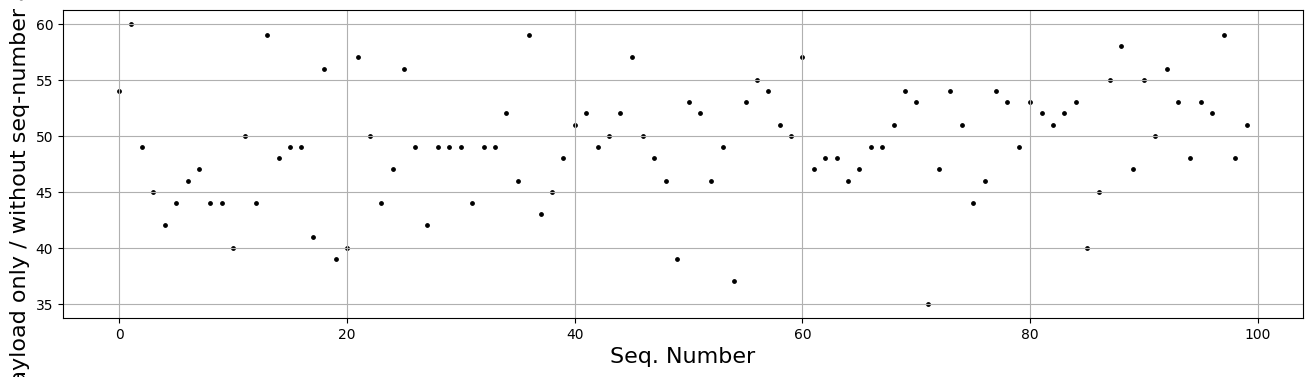

In [9]:
# BER for each packet
print("Note: if individual packets have a high bit-error rate, it could be that the pseudo-sequence number was corrupted and the script could not identify the expected payload correctly.")
plt.scatter(range(len(df)), [compute_ber_packet(row,PACKET_LEN=NUM_16RND*2)[0] for (_,row) in df.iterrows()], marker='o', s=6, color='black')
plt.grid()
plt.ylabel('Bit Error Rate [%] (payload only / without seq-number and pseudo-seq-number)', fontsize=16)
plt.xlabel('Seq. Number', fontsize=16)

# Distance

## Definition

**The communication distance of the system.**
<br>$D_{1}$: the distance between carrier<->backscatter_tag[m]
<br>$D_{2}$: the distance between backscatter_tag<->receiver[m]
<br> Distance metric = $D_{1}^2D_{2}^2$
<br>

In [10]:
# record the distance
dis_carrier_tag = 0.3
dis_tag_rx = 1.3

dis_metric = dis_carrier_tag**2*dis_tag_rx**2
print(f"Distance metric is: {dis_metric}")

Distance metric is: 0.1521


# Radarplot

**Please pay attention to the unit**
<br> <font color='red'>Time</font>: use second as unit
<br> <font color='red'>Reliability</font>: use the percent as unit
<br> <font color='red'>Distance</font>: use meter as unit
<br>**Metics = [Time(s), Reliability(%), Distance(m)]**
<br> <font color='red'>Always keep the reference in your plot.</font>
<br> Tips: for ploting, time metric uses $\frac{1}{Time}*1000$ as the time metric, the higher the value the better the system performance

[np.float64(48.274), 56.03571428571428, 0.1521]


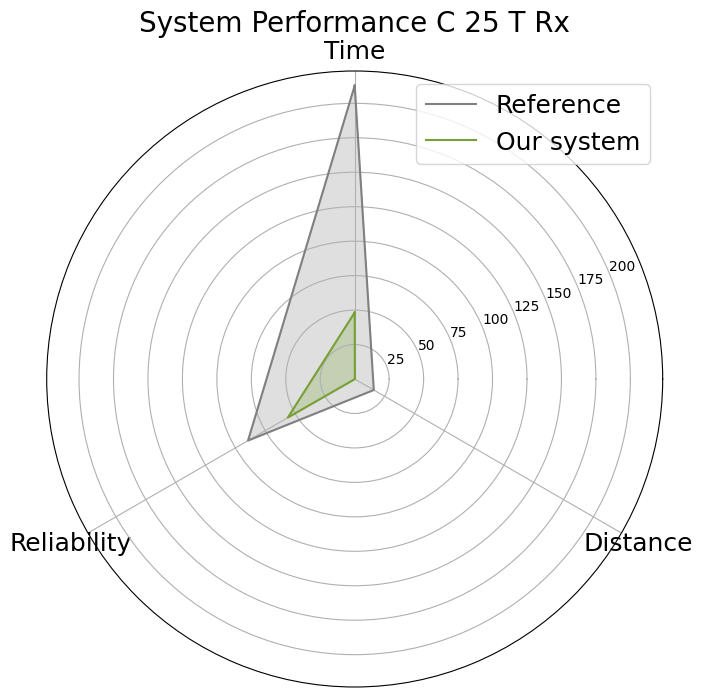

In [11]:
metrics = [file_delay_s, bit_reliability, dis_metric]

system_ref_baseline_c25 = [57.284, 96.41, 16] # C ->(25cm) Tag
system_ref_baseline_c50 = [np.float64(100.318), 92.21428571428572, 16] # C ->(50cm) Tag
system_ref_baseline_middle = [0, 0, 0] # C -> (150) Tag -> (150) Receiver
system_ref_baseline_rx50 = [np.float64(212.826), 89.36160714285715, 16] # Tag ->(50cm) Receiver
system_ref_baseline_rx25 = [np.float64(121.055), 91.36607142857143, 16] # # Tag ->(25cm) Receiver


print(metrics)
#                                                 25cm                            3m
title = "System Performance C 25 T Rx" # Carrier ------> Tag -> Receiver (Carrier --> Receiver)
radar_plot(metrics, system_ref=system_ref_baseline_rx50, title=title)

# Frequency offset sweep

Compare PER, BER, and mean RSSI across multiple captured files at different
backscatter frequency offsets. Drop CSVs in this folder, list them in the
`sweep` dict below, and run the analysis cell.

Offsets use *achieved* values (PIO clock 125 MHz / divider d1).
**`d1` must be even** — odd values trigger a runtime warning on the Pico
("the clock divider d1 has to be an even integer") and the state machine may
not produce a valid tone.

| Target [MHz] | d1 (even) | Achieved [MHz] | SmartRF RX freq [MHz] |
|--------------|-----------|----------------|------------------------|
| 0.5          | 250       | 0.500          | 868.500                |
| 1            | 124       | 1.008          | 869.008                |
| 2            | 62        | 2.016          | 870.016                |
| 3            | 42        | 2.976          | 870.976                |
| 5            | 24        | 5.208          | 873.208                |
| 7 (baseline) | 18        | 6.944          | 874.944                |
| 9            | 14        | 8.929          | 876.929                |
| 12           | 10        | 12.500         | 880.500                |
| 15           | 8         | 15.625         | 883.625                |
| 20           | 6         | 20.833         | 888.833                |


In [12]:
# Map achieved offset (MHz) -> filename (without .csv extension).
# All d1 values below are EVEN, as required by the PIO state machine.
# Comment out / delete entries for files you haven't captured yet.

sweep = {
    0.500:  "2-ASK_0,5",            # d1=250, RX 868.500 MHz
    1.008:  "2-ASK_1,0",            # d1=124, RX 869.008 MHz
    2.016:  "2-ASK_2,0",            # d1=62,  RX 870.016 MHz
    2.976:  "2-ASK_3,0",            # d1=42,  RX 870.976 MHz
    5.208:  "2-ASK_5,0",            # d1=24,  RX 873.208 MHz
    6.944:  "150_30_2-ASK_6,444",   # d1=18,  RX 874.944 MHz  (baseline)
    8.929:  "2-ASK_9,0",            # d1=14,  RX 876.929 MHz
    12.500: "2-ASK_12,0",           # d1=10,  RX 880.500 MHz
    15.625: "2-ASK_15,0",           # d1=8,   RX 883.625 MHz
    20.833: "2-ASK_20,0",           # d1=6,   RX 888.833 MHz
}


The total number of packets transmitted by the tag is 17.
The total number of packets transmitted by the tag is 196.
The total number of packets transmitted by the tag is 129.
The total number of packets transmitted by the tag is 197.
The total number of packets transmitted by the tag is 155.
The total number of packets transmitted by the tag is 67.
The total number of packets transmitted by the tag is 229.
The total number of packets transmitted by the tag is 85.
The total number of packets transmitted by the tag is 180.
The total number of packets transmitted by the tag is 24.
            received    lost    sent    per    ber  mean_rssi
offset_MHz                                                   
0.500          100.0  1005.0  1105.0  90.95  43.23    -103.37
1.008          100.0     4.0   104.0   3.85  17.96    -101.54
2.016          100.0    28.0   128.0  21.88  40.88    -102.36
2.976          100.0     4.0   104.0   3.85  12.59     -99.34
5.208          100.0     4.0   104.0   3.8

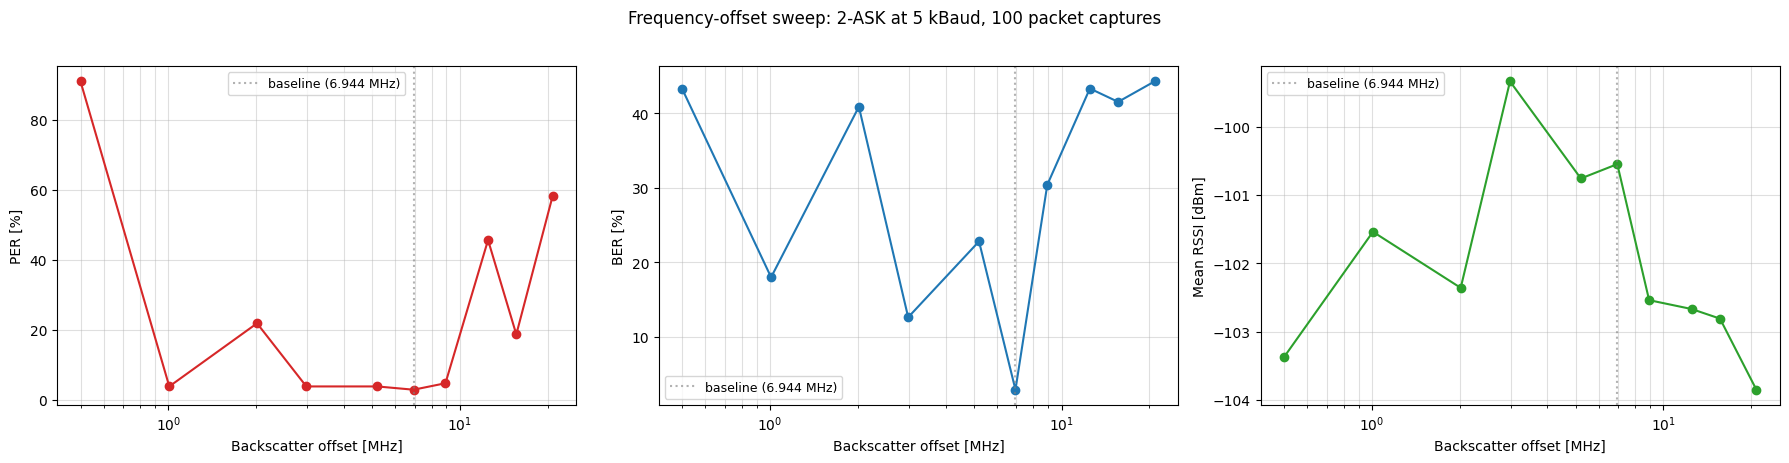

In [13]:
# Load each file in `sweep`, compute metrics, and plot a 3-panel comparison:
#   - PER (gap-based)
#   - BER (received packets only)
#   - Mean RSSI

import os

NOMINAL_PERIOD_MS = 268.2  # empirical, from baseline analysis
PACKET_LEN_BYTES  = NUM_16RND * 2

def analyze_file(path):
    """Return dict of metrics for one capture file, or None if file missing."""
    if not os.path.isfile(path):
        return None
    d = readfile(path)
    valid = d[d.payload.apply(lambda x: len(x) == ((PAYLOADSIZE) * 3 - 1))].reset_index()
    gaps = d.time_rx.diff().dt.total_seconds() * 1000
    est_lost = ((gaps / NOMINAL_PERIOD_MS).round() - 1).clip(lower=0).fillna(0).astype(int).sum()
    sent = len(d) + int(est_lost)
    return {
        "received":  len(d),
        "lost":      int(est_lost),
        "sent":      sent,
        "per":       int(est_lost) / sent * 100 if sent else float("nan"),
        "ber":       compute_ber(valid, PACKET_LEN=PACKET_LEN_BYTES) * 100 if len(valid) else float("nan"),
        "mean_rssi": d.rssi.mean(),
    }

results = {}
for offset_mhz, fname in sweep.items():
    metrics = analyze_file(f"./{fname}.csv")
    if metrics is None:
        print(f"[skip] {offset_mhz:6.3f} MHz — file '{fname}.csv' not found")
        continue
    results[offset_mhz] = metrics

if not results:
    raise RuntimeError("No sweep files found. Drop CSVs into stats/ and update the `sweep` dict.")

summary = pd.DataFrame(results).T.sort_index()
summary.index.name = "offset_MHz"
print(summary.round(2))

# Plot: 3 panels side by side, x-axis = offset (log scale to span 0.5..20)
fig, (ax_per, ax_ber, ax_rssi) = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, col, ylabel, color in [
    (ax_per,  "per",       "PER [%]",        "tab:red"),
    (ax_ber,  "ber",       "BER [%]",        "tab:blue"),
    (ax_rssi, "mean_rssi", "Mean RSSI [dBm]", "tab:green"),
]:
    ax.plot(summary.index, summary[col], marker="o", color=color, linewidth=1.5)
    ax.set_xscale("log")
    ax.set_xlabel("Backscatter offset [MHz]")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", alpha=0.4)
    # annotate the baseline point
    if 6.944 in summary.index:
        ax.axvline(6.944, color="grey", linestyle=":", alpha=0.6, label="baseline (6.944 MHz)")
        ax.legend(loc="best", fontsize=9)

fig.suptitle("Frequency-offset sweep: 2-ASK at 5 kBaud, 100 packet captures", y=1.02)
plt.tight_layout()
plt.show()
